In [2]:
import numpy as np
print(np.__version__)

2.1.3


In [3]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import requests
from io import StringIO

pio.renderers.default = "iframe"

url = "https://www.openintro.org/data/csv/possum.csv"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

df = pd.read_csv(StringIO(response.text))

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   site     104 non-null    int64  
 1   pop      104 non-null    object 
 2   sex      104 non-null    object 
 3   age      102 non-null    float64
 4   head_l   104 non-null    float64
 5   skull_w  104 non-null    float64
 6   total_l  104 non-null    float64
 7   tail_l   104 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 6.6+ KB


In [5]:
df.describe

<bound method NDFrame.describe of      site    pop sex  age  head_l  skull_w  total_l  tail_l
0       1    Vic   m  8.0    94.1     60.4     89.0    36.0
1       1    Vic   f  6.0    92.5     57.6     91.5    36.5
2       1    Vic   f  6.0    94.0     60.0     95.5    39.0
3       1    Vic   f  6.0    93.2     57.1     92.0    38.0
4       1    Vic   f  2.0    91.5     56.3     85.5    36.0
..    ...    ...  ..  ...     ...      ...      ...     ...
99      7  other   m  1.0    89.5     56.0     81.5    36.5
100     7  other   m  1.0    88.6     54.7     82.5    39.0
101     7  other   f  6.0    92.4     55.0     89.0    38.0
102     7  other   m  4.0    91.5     55.2     82.5    36.5
103     7  other   f  3.0    93.6     59.9     89.0    40.0

[104 rows x 8 columns]>

# Data Summary of "head_l" column 
# in Possum Dataset

The more spread out the data, the larger the variance and standard deviation.

In [6]:


# 1. Population Variance 
population_variance = df['head_l'].var(ddof=0)

# 2. Sample Variance 
sample_variance = df['head_l'].var()

# 3. Standard Deviation (sample standard deviation)
std_dev = df['head_l'].std()
mean = df['head_l'].mean()
print(f"Population Variance: {population_variance:.4f}")
print(f"Sample Variance: {sample_variance:.4f}")
print(f"Standard Deviation: {std_dev:.4f}")
print("-" * 30)


Population Variance: 12.6460
Sample Variance: 12.7688
Standard Deviation: 3.5733
------------------------------


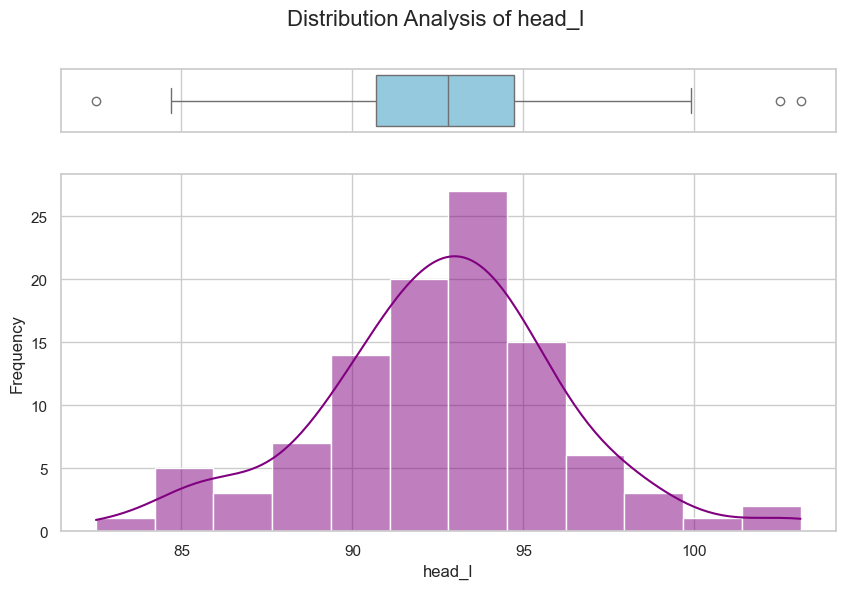

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#style 
sns.set_theme(style="whitegrid")

# 1. placing histogram and boxplotn in a single frame
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                      gridspec_kw={"height_ratios": (.15, .85)}, 
                                      figsize=(10, 6))

# generating boxplot
sns.boxplot(x=df['head_l'], ax=ax_box, color='skyblue')
ax_box.set(xlabel='') 

# generating a histogram
sns.histplot(x=df['head_l'], ax=ax_hist, kde=True, color='purple')
ax_hist.set(xlabel='head_l', ylabel='Frequency')

plt.suptitle('Distribution Analysis of head_l', fontsize=16)
plt.show()

head_l column looks like it's normally distributed.

- Looking at the boxplot, the whisker lengths are similar. There are 3 outliers out of 104 total data points, so it is not a perfect normal distribution, but it is not too hard to say that it follows a normal distribution.

- Looking at the histogram, the graph has a bell shape going up in the middle. This can show that the data follows a normal distribution. 

Assuming that it follows a normal distribution, let's analyze the 68-95-99.7 rule. 

In [17]:
# 
count_1std = ((df['head_l'] >= mean - 1 * std_dev) & (df['head_l'] <= mean + 1 * std_dev)).sum() / len(df)
count_2std = ((df['head_l'] >= mean - 2 * std_dev) & (df['head_l'] <= mean + 2 * std_dev)).sum() / len(df)
count_3std = ((df['head_l'] >= mean - 3 * std_dev) & (df['head_l'] <= mean + 3 * std_dev)).sum() / len(df)

print("Empirical Rule Analysis:")
print(f"Within 1 std dev (68% expected): {count_1std:.2%}")
print(f"Within 2 std dev (95% expected): {count_2std:.2%}")
print(f"Within 3 std dev (99.7% expected): {count_3std:.2%}")

Empirical Rule Analysis:
Within 1 std dev (68% expected): 75.00%
Within 2 std dev (95% expected): 93.27%
Within 3 std dev (99.7% expected): 100.00%


Since 75% of the data in the head_l column is within 1 SD, the data is very concentrated near the mean. There are more data points close to the center value than in a normal distribution. 

## Practice Questions
Why can't we simply average deviations from the mean?
- For example, if we assume there is a dataset like 2, 4, 6, 8, 10, the average of deviations from the mean becomes 0.

Why are deviations squared?
- It is to prevent the sum of deviations from becoming 0.

Why do we divide by n-1 for a sample?
- It is to reduce the error compared to the population variance.

Can standard deviation ever be negative?
- no

Which dataset is more consistent: SD = 2 or SD = 15?
- dataset which has SD of 2 is more consistent. The bigger SD, the more inconsistent datas are.

How do outliers affect variance and standard deviation?
- Outliers have a very big effect on variance and standard deviation.

When is standard deviation more useful than variance
- Standard deviation has the same unit as the original data because it is the square root of variance, so it is more intuitive and easier to understand than variance when comparing data characteristics.